In [11]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from meteostat import Point, Hourly, Stations
from tqdm import tqdm
import sys
import numpy as np

In [12]:
sys.path.append('Utils/')
from PlotUtils import setMplParam, getColour, getHistoParam 
# getHistoParam: 
# Nbins, binwidth, bins, counts, bin_centers  = 
# from ExternalFunctions import nice_string_output, add_text_to_ax
setMplParam()
from DataPipelineWorkShop import get_hourly_example, MeteoPreprocessor

In [13]:
kbh = Point(lat=55.6761, lon=12.5683)
df_true = get_hourly_example(kbh, start=datetime(2019, 6, 1), end=datetime(2019, 6, 3))

In [14]:
df_true.columns

Index(['temp', 'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres',
       'tsun', 'coco'],
      dtype='object')

In [24]:
df_true[['temp', 'rhum', 'prcp', 'wdir', 'wspd']]

,temp,rhum,prcp,wdir,wspd
time,,,,,
2019-06-01 00:00:00,13.0,99.0,0.0,230.0,11.2
2019-06-01 01:00:00,13.6,96.0,<NA>,240.0,16.6
2019-06-01 02:00:00,13.7,97.0,<NA>,210.0,11.2
2019-06-01 03:00:00,13.8,96.0,<NA>,210.0,14.8
2019-06-01 04:00:00,13.5,94.0,<NA>,220.0,11.2
2019-06-01 05:00:00,14.1,91.0,<NA>,200.0,16.6
2019-06-01 06:00:00,14.7,86.0,0.0,210.0,18.4
2019-06-01 07:00:00,15.0,88.0,<NA>,220.0,18.4
2019-06-01 08:00:00,16.1,81.0,<NA>,210.0,20.5


In [16]:
prediction_file = "/Users/yhjo/Desktop/[2025] Be Resilient/Resilience/logs/20251107/131556/predictions/20251108_152802.csv"

In [17]:
df_pred = pd.read_csv(prediction_file)
df_pred.columns

Index(['window', 'time', 'temp', 'rhum', 'prcp', 'wspd', 'sin_wdir',
       'cos_wdir'],
      dtype='object')

In [18]:
processor = MeteoPreprocessor()
df_pred_inv = processor.inverse_transform(df_pred)

In [19]:
df_pred_inv

,window,time,temp,rhum,prcp,wspd,wdir
0,0,2019-06-01 01:00:00,12.581876,91.486496,0.118883,12.729658,241.236092
1,0,2019-06-01 02:00:00,12.852600,92.103159,0.087676,12.817369,243.325919
2,0,2019-06-01 03:00:00,12.301032,93.403453,0.085259,12.377374,243.563117
3,0,2019-06-01 04:00:00,12.336025,92.979723,0.085779,12.637491,243.361531
4,0,2019-06-01 05:00:00,12.373014,92.754138,0.079372,12.872429,244.193354
...,...,...,...,...,...,...,...
163,13,2019-06-01 21:00:00,15.067495,81.750071,0.050304,12.317730,129.565062
164,13,2019-06-01 22:00:00,14.187547,85.839820,0.036868,12.031035,129.391775
165,13,2019-06-01 23:00:00,13.965131,86.879271,0.033892,11.994429,123.469032
166,13,2019-06-02 00:00:00,13.370473,89.395165,0.009672,12.218727,137.051778


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


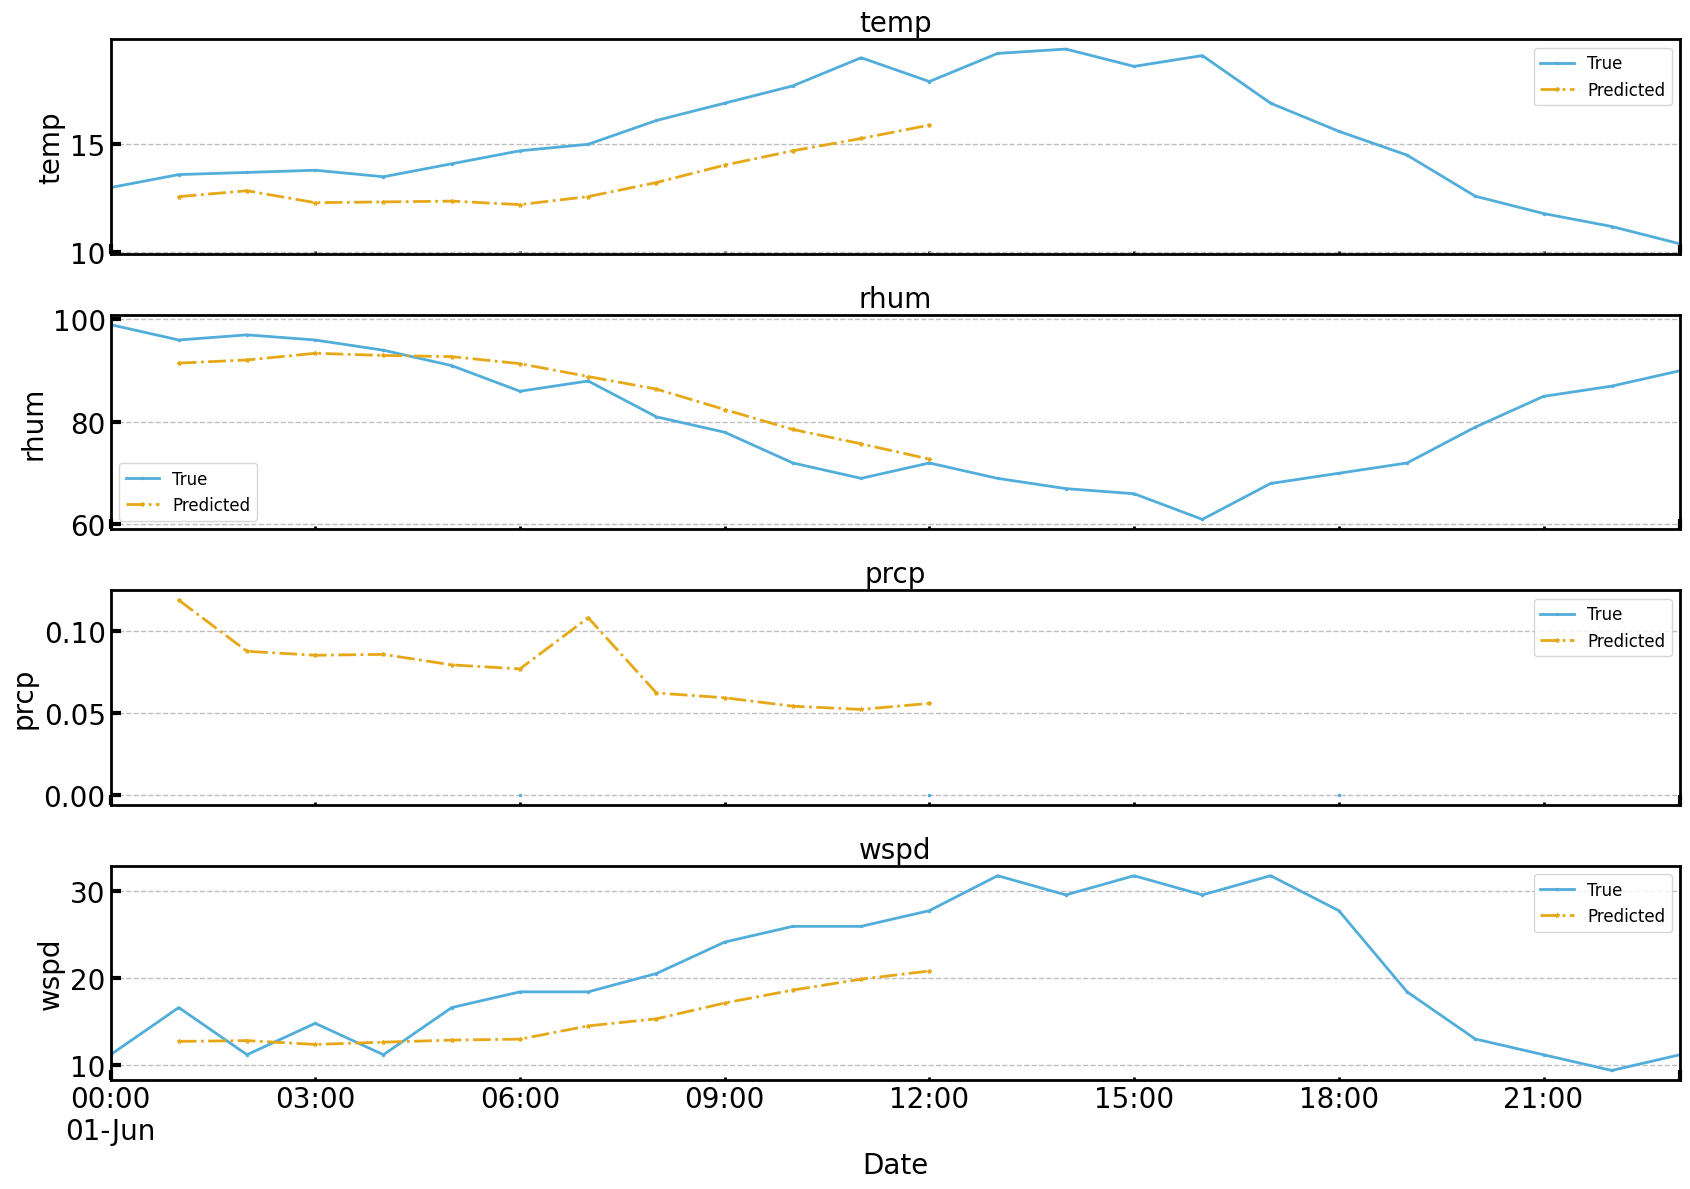

In [27]:
def plot_hourly_features(
    df_true: pd.DataFrame,
    df_pred: pd.DataFrame,
    features: list[str] = ['temp', 'rhum', 'prcp', 'wspd']
) -> None:
    df_true = df_true[:24]
    df_pred = df_pred[df_pred['window'] == 0]
    # --- normalise time index for df_true ---
    if 'time' in df_true.columns:
        df_true['time'] = pd.to_datetime(df_true['time'])
        df_true = df_true.set_index('time')
    elif isinstance(df_true.index, pd.PeriodIndex):
        df_true.index = df_true.index.to_timestamp()

    # --- normalise time index for df_pred ---
    if 'time' in df_pred.columns:
        df_pred['time'] = pd.to_datetime(df_pred['time'])
        df_pred = df_pred.set_index('time')
    elif isinstance(df_pred.index, pd.PeriodIndex):
        df_pred.index = df_pred.index.to_timestamp()

    n_features = len(features)
    fig, axes = plt.subplots(n_features, 1, figsize=(17, 3*n_features), sharex=True)
    if n_features == 1:
        axes = [axes]

    for ax, feature in zip(axes, features):
        df_true[feature].plot(ax=ax, label="True")
        df_pred[feature].plot(ax=ax, label="Predicted")
        ax.set_title(feature)
        ax.set_ylabel(feature)
        ax.legend()

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()


plot_hourly_features(df_true, df_pred_inv, features=['temp', 'rhum', 'prcp', 'wspd'])